In [4]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install -U scikit-learn
!pip install statsmodels
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]


In [2]:
from pathlib import Path

print(Path.cwd())

/Users/inwoopark/workspace/window_home/7월27일,28일


In [3]:
file_path = Path("ENB2012_data.xlsx")

print(file_path.exists())

True


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel(file_path)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Overall_Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Area_Distribution",
    "Heating_Load",
    "Cooling_Load",
]
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [7]:
df.shape

(768, 10)

In [8]:
df.isnull().sum()

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

In [13]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


count 다 같음
mean 과 50% 비교 : 차이가 크지 않음, heating_load 치우침 있나?
std : 
비정상적 min max

## 범주형 데이터 한번 확인

In [11]:
df["Orientation"].value_counts()

Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64

In [10]:
df["Glazing_Area_Distribution"].value_counts()

Glazing_Area_Distribution
1    144
2    144
3    144
4    144
5    144
0     48
Name: count, dtype: int64

중앙 평균값 비교

In [14]:
mean_median = pd.DataFrame({
    "mean": df.mean(numeric_only=True),
    "median": df.median(numeric_only=True)
})

mean_median["difference"] = (
    mean_median["mean"] - mean_median["median"]
)

mean_median

,mean,median,difference
Relative_Compactness,0.764167,0.75,0.014167
Surface_Area,671.708333,673.75,-2.041667
Wall_Area,318.500000,318.50,0.000000
Roof_Area,176.604167,183.75,-7.145833
Overall_Height,5.250000,5.25,0.000000
Orientation,3.500000,3.50,0.000000
Glazing_Area,0.234375,0.25,-0.015625
Glazing_Area_Distribution,2.812500,3.00,-0.187500
Heating_Load,22.307195,18.95,3.357195
Cooling_Load,24.587760,22.08,2.507760


Wall_Area, Overall_Height
평균과 중앙값이 같아서 대칭에 가까워 보임.
Heating_Load
평균 22.31 > 중앙값 18.95
→ 큰 값 쪽으로 치우친 양의 왜도 가능성
Cooling_Load
평균 24.59 > 중앙값 22.08
→ 역시 오른쪽 치우침 가능성
Roof_Area, Glazing_Area
평균 < 중앙값
→ 작은 값 쪽으로 치우친 음의 왜도 가능성

In [15]:
df.skew(numeric_only=True).sort_values()

Roof_Area                   -0.162764
Surface_Area                -0.125131
Glazing_Area_Distribution   -0.088689
Glazing_Area                -0.060254
Overall_Height               0.000000
Orientation                  0.000000
Heating_Load                 0.360446
Cooling_Load                 0.395992
Relative_Compactness         0.495513
Wall_Area                    0.533417
dtype: float64

Roof_Area, Surface_Area: 약한 왼쪽 치우침
Heating_Load, Cooling_Load: 약한 오른쪽 치우침
Relative_Compactness: 오른쪽 치우침이 조금 있음
Wall_Area: 오른쪽 치우침이 비교적 가장 큼
대부분 |왜도| < 1이라 심하게 치우친 변수는 없음

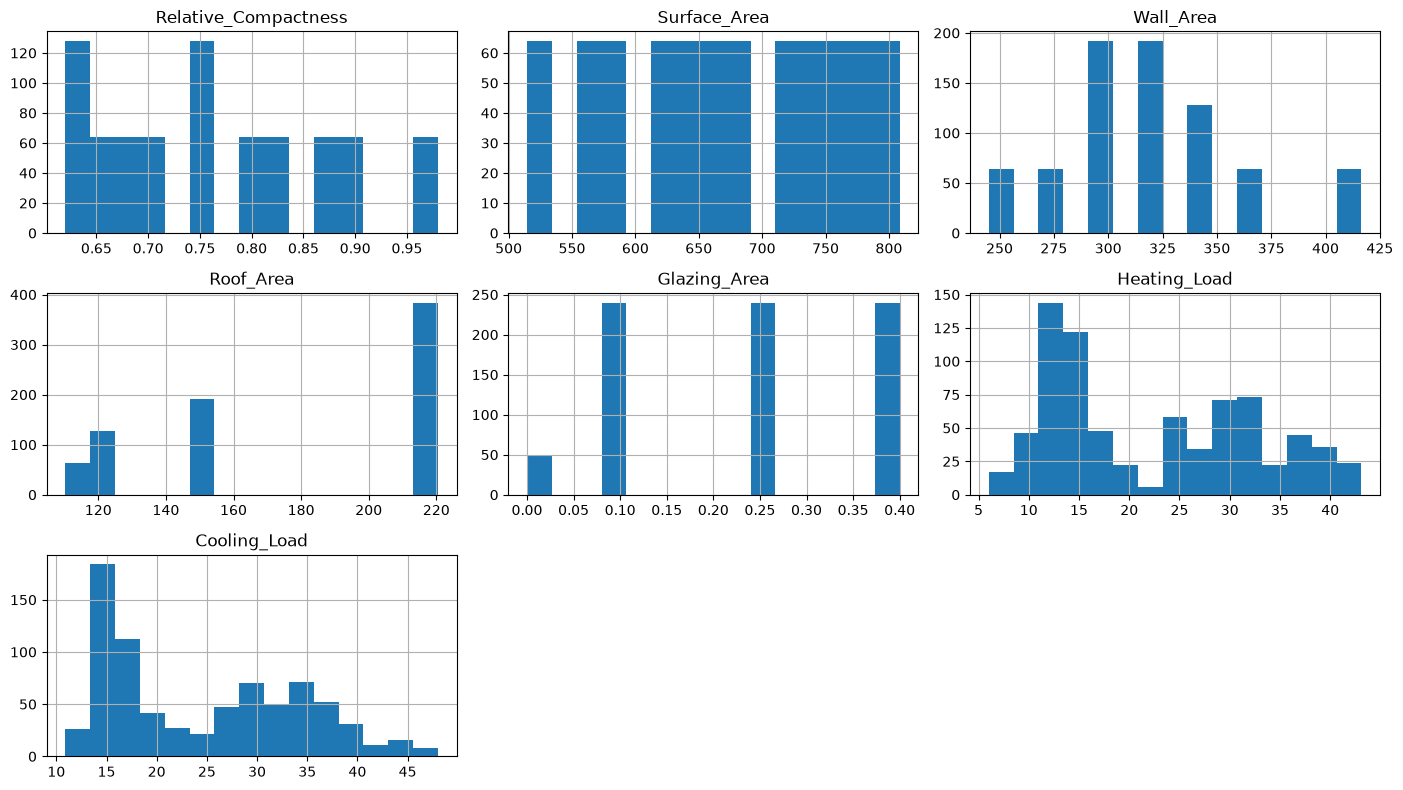

In [18]:
cols = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Glazing_Area",
    "Heating_Load",
    "Cooling_Load",
]

df[cols].hist(
    figsize=(14, 8),
    bins=15
)

plt.tight_layout()
plt.show()

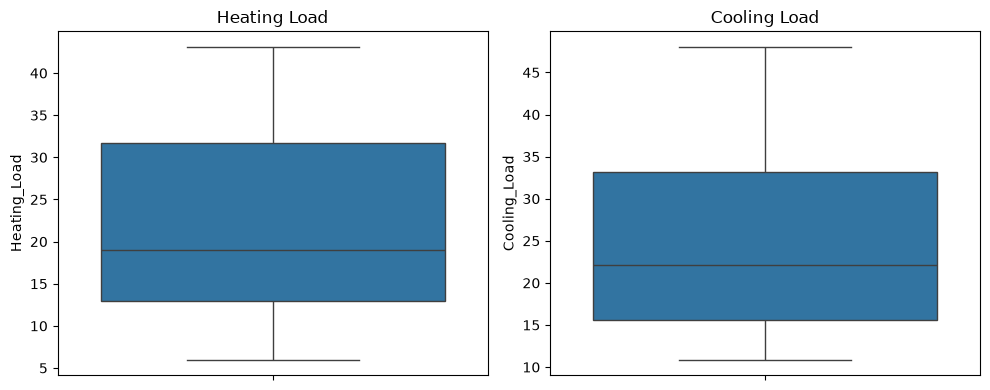

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df["Heating_Load"], ax=axes[0])
axes[0].set_title("Heating Load")

sns.boxplot(y=df["Cooling_Load"], ax=axes[1])
axes[1].set_title("Cooling Load")

plt.tight_layout()
plt.show()

수염 밖에 점이 없음 → IQR 기준 뚜렷한 이상치 후보는 없음
두 변수 모두 중앙값이 상자의 아래쪽에 있음
위쪽 수염이 아래쪽보다 김 → 높은 부하 방향으로 약간 치우침
앞에서 계산한 양의 왜도와 일치함
Heating_Load, Cooling_Load 모두 값의 퍼짐이 꽤 넓음

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

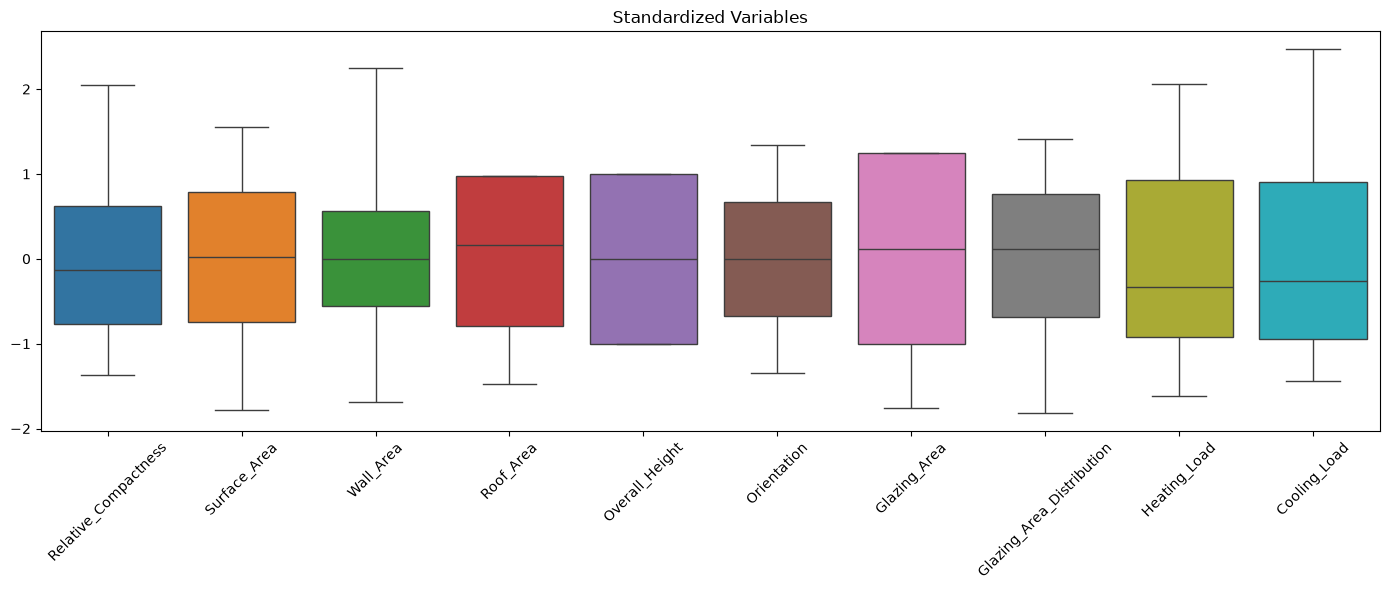

In [25]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df_scaled)

plt.xticks(rotation=45)
plt.title("Standardized Variables")
plt.tight_layout()
plt.show()

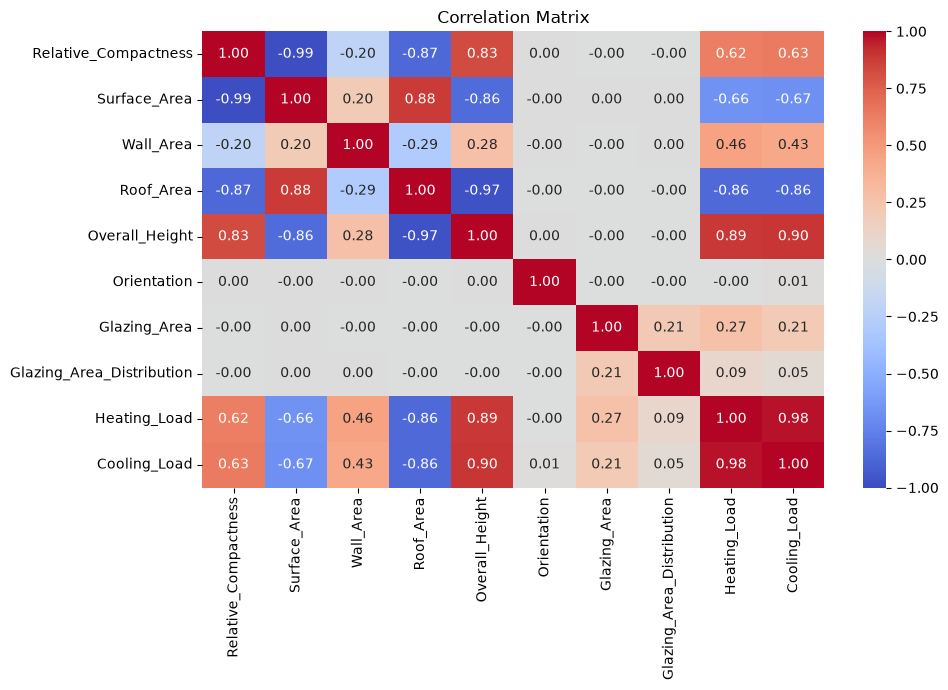

In [29]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Overall_Height
Heating 0.89
Cooling 0.90
→ 높이가 큰 집단일수록 냉난방 부하가 높은 경향
Roof_Area
둘 다 -0.86
→ 지붕 면적이 클수록 냉난방 부하는 낮은 경향
Surface_Area
-0.66, -0.67
→ 비교적 강한 음의 관계
Relative_Compactness
0.62, 0.63
→ 비교적 강한 양의 관계
Heating_Load와 Cooling_Load
0.98
→ 두 목표값이 거의 같은 방향으로 움직임

Relative_Compactness ↔ Surface_Area = -0.99
Roof_Area ↔ Overall_Height          = -0.97

# 가장 강한 변수 직접 확인

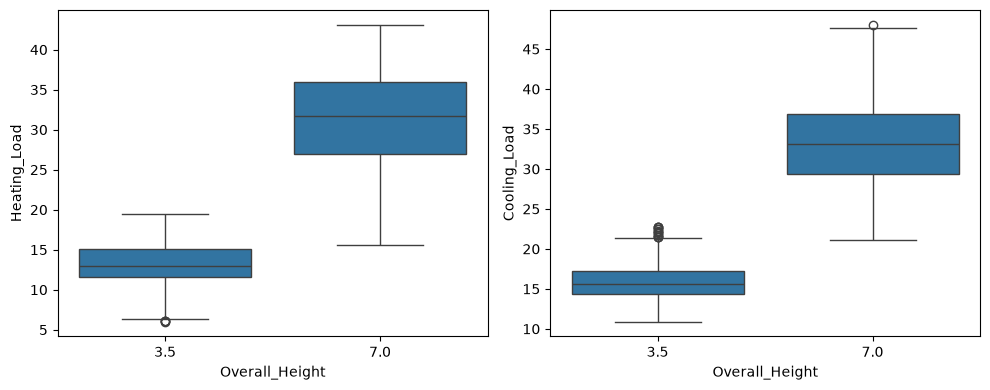

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Overall_Height",
    y="Heating_Load",
    ax=axes[0]
)

sns.boxplot(
    data=df,
    x="Overall_Height",
    y="Cooling_Load",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [33]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Orientation",
        "Glazing_Area_Distribution"
    ],
    dtype=int
)

df_encoded.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Glazing_Area,Heating_Load,Cooling_Load,Orientation_2,Orientation_3,Orientation_4,Orientation_5,Glazing_Area_Distribution_0,Glazing_Area_Distribution_1,Glazing_Area_Distribution_2,Glazing_Area_Distribution_3,Glazing_Area_Distribution_4,Glazing_Area_Distribution_5
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,1,0,0,0,1,0,0,0,0,0
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,1,0,0,1,0,0,0,0,0
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,1,0,1,0,0,0,0,0
3,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,0,1,1,0,0,0,0,0
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84,28.28,1,0,0,0,1,0,0,0,0,0


In [34]:
target_corr = df_encoded.corr()[
    ["Heating_Load", "Cooling_Load"]
]

target_corr = target_corr.drop(
    index=["Heating_Load", "Cooling_Load"]
)

target_corr

,Heating_Load,Cooling_Load
Relative_Compactness,0.622272,0.634339
Surface_Area,-0.658120,-0.672999
Wall_Area,0.455671,0.427117
Roof_Area,-0.861828,-0.862547
Overall_Height,0.889430,0.895785
Glazing_Area,0.269842,0.207505
Orientation_2,0.000325,0.001018
Orientation_3,0.004207,-0.016713
Orientation_4,-0.002709,-0.006525
Orientation_5,-0.001823,0.022220


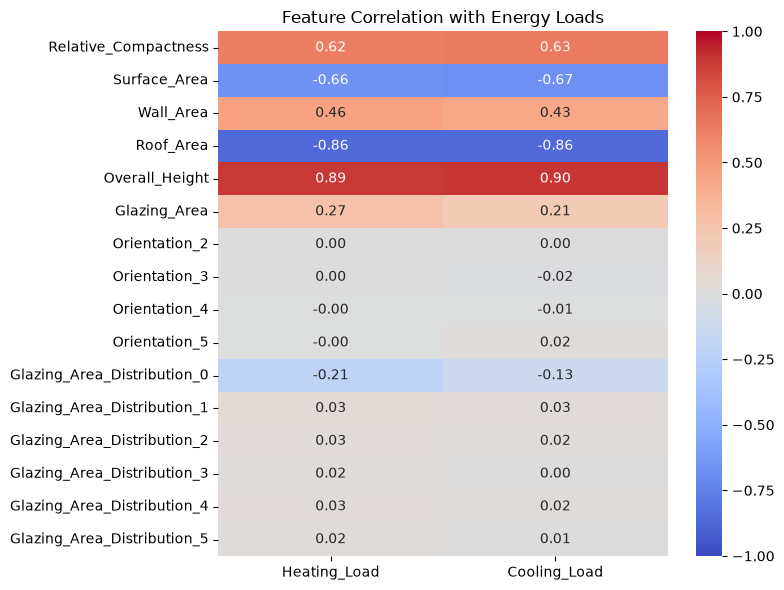

In [37]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Feature Correlation with Energy Loads")
plt.tight_layout()
plt.show()

Orientation

Orientation_2 ~ Orientation_5
상관계수 약 -0.02 ~ 0.02

각 방향 여부와 냉난방 부하의 단순한 관계가 거의 없음을 뜻해. 방향별 평균도 비슷할 가능성이 높지만, 상관계수만으로 최종 제거하면 안 돼.

Glazing_Area_Distribution

분포 1~5: 상관계수 약 0.00~0.03

창문 배치 방식 자체는 냉난방 부하와 단순 관계가 매우 약해 보여.

하지만 Distribution_0은:

Heating_Load: -0.21
Cooling_Load: -0.13

이 값만 조금 크게 나타났어. 주의할 점은 Distribution=0이 보통 Glazing_Area=0인 건물, 즉 창 면적이 없는 경우와 연결되어 있을 가능성이 크다는 거야.

따라서 이것을:

창 배치를 0번으로 하면 에너지 부하가 감소한다

라고 해석하면 안 되고,

창 면적이 없는 집단이 다른 집단보다 부하가 낮게 나타났을 가능성

으로 봐야 해.

다음 단계: 방향별 실제 평균 확인

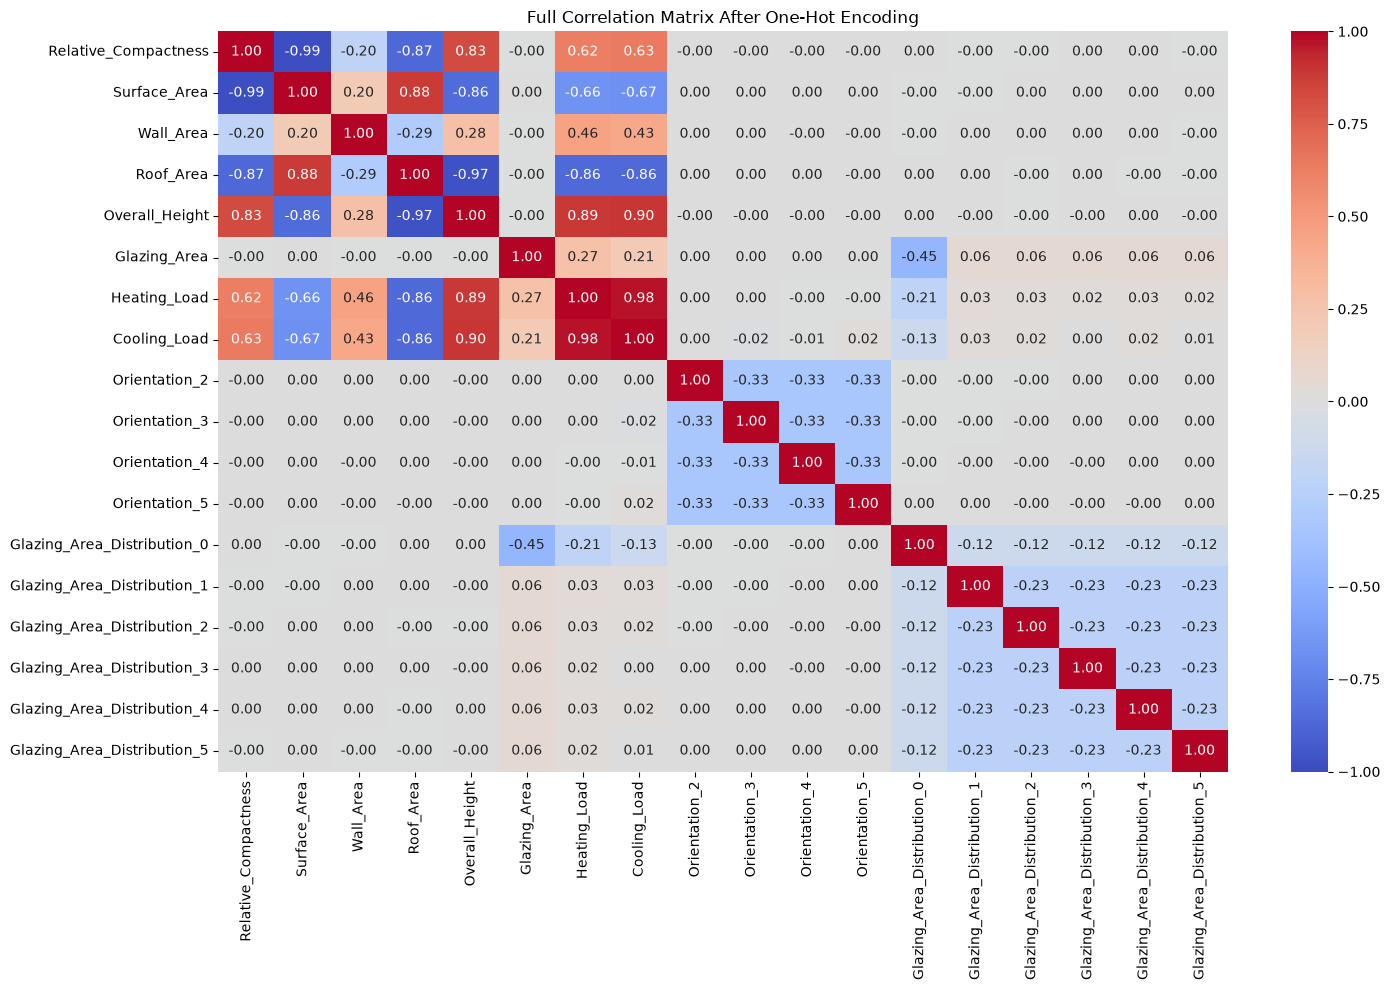

In [44]:
corr_encoded = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(15, 10))

sns.heatmap(
    corr_encoded,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Full Correlation Matrix After One-Hot Encoding")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Relative_Compactness ↔ Surface_Area	-0.99
Roof_Area ↔ Overall_Height	-0.97
Surface_Area ↔ Roof_Area	0.88
Relative_Compactness ↔ Roof_Area	-0.87
Surface_Area ↔ Overall_Height	-0.86
Relative_Compactness ↔ Overall_Height	0.83

Glazing_Area ↔ Distribution_0 = -0.45

이는 Distribution_0이 창문 배치의 독립 효과라기보다 창 면적이 0인 경우와 연결되어 있기 때문일 가능성이 큼

원핫 변수끼리 나타나는 -0.12, -0.23도 범주가 서로 동시에 선택될 수 없어서 생기는 자연스러운 관계

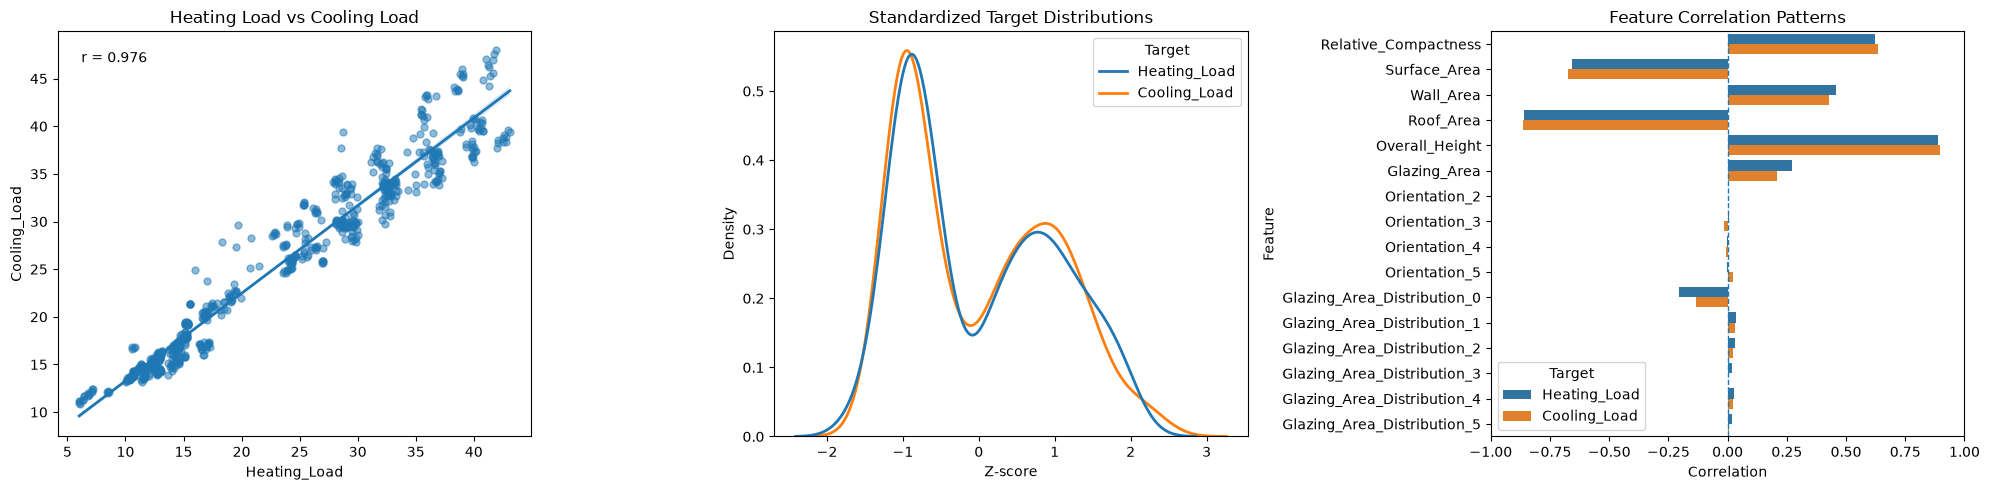

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

targets = ["Heating_Load", "Cooling_Load"]

# 원핫 인코딩된 데이터 기준
feature_cols = [
    col for col in df_encoded.columns
    if col not in targets
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --------------------------------------------------
# 1. Heating Load와 Cooling Load의 직접적인 관계
# --------------------------------------------------
target_corr = df[targets].corr().iloc[0, 1]

sns.regplot(
    data=df,
    x="Heating_Load",
    y="Cooling_Load",
    scatter_kws={"alpha": 0.5, "s": 25},
    line_kws={"linewidth": 2},
    ax=axes[0]
)

axes[0].set_title("Heating Load vs Cooling Load")
axes[0].text(
    0.05,
    0.95,
    f"r = {target_corr:.3f}",
    transform=axes[0].transAxes,
    verticalalignment="top"
)

# --------------------------------------------------
# 2. 두 타깃의 표준화된 분포 비교
# --------------------------------------------------
target_scaled = df[targets].apply(zscore)

target_long = target_scaled.melt(
    var_name="Target",
    value_name="Standardized value"
)

sns.kdeplot(
    data=target_long,
    x="Standardized value",
    hue="Target",
    common_norm=False,
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title("Standardized Target Distributions")
axes[1].set_xlabel("Z-score")

# --------------------------------------------------
# 3. 독립변수와의 상관계수 패턴 비교
# --------------------------------------------------
target_feature_corr = (
    df_encoded[feature_cols + targets]
    .corr()[targets]
    .drop(index=targets)
    .reset_index()
    .rename(columns={"index": "Feature"})
    .melt(
        id_vars="Feature",
        var_name="Target",
        value_name="Correlation"
    )
)

sns.barplot(
    data=target_feature_corr,
    y="Feature",
    x="Correlation",
    hue="Target",
    ax=axes[2]
)

axes[2].axvline(0, linestyle="--", linewidth=1)
axes[2].set_title("Feature Correlation Patterns")
axes[2].set_xlim(-1, 1)

plt.tight_layout()
plt.show()